In [34]:
import pandas as pd
import numpy as np

np.random.seed(123)
n_sample=1000
class_0_ratio = 0.9
n_class_0 = int(n_sample*class_0_ratio)
n_class_1=n_sample-n_class_0

In [35]:
n_class_0,n_class_1

(900, 100)

In [123]:
#creating dataframe with imbalance dataset
class_0=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_0),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_0),
    'target':[0]*n_class_0
})
class_1=pd.DataFrame({
    'feature_1':np.random.normal(loc=0,scale=1,size=n_class_1),
    'feature_2':np.random.normal(loc=0,scale=1,size=n_class_1),
    'target':[1]*n_class_1
})
df=pd.concat([class_0,class_1])
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

### Downsampling

In [143]:
# downsampling
from sklearn.utils import resample
df_minority=df[df['target']==1]
df_minority
df_majority=df[df['target']==0]
df_majority_downsampled=resample(df_majority,replace=True,n_samples=len(df_minority),random_state=42)
df_downsampled=pd.concat([df_majority_downsampled,df_minority])
df_downsampled['target'].value_counts()

target
0    100
1    100
Name: count, dtype: int64

### Upsampling

In [142]:
df_minority_upsampled=resample(df_minority,replace=True,n_samples=len(df_majority),random_state=42)
df_upsampled=pd.concat([df_minority_upsampled,df_majority])
df_upsampled['target'].value_counts()

target
1    900
0    900
Name: count, dtype: int64

Text(0.5, 1.0, 'Imbalanced Dataset')

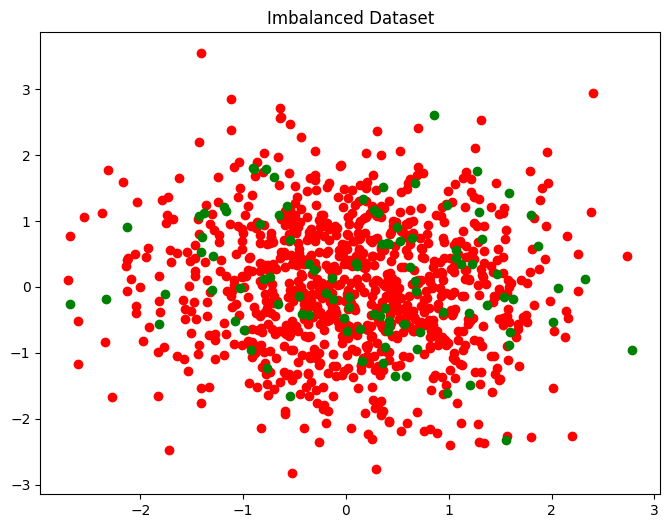

In [145]:
import matplotlib.pyplot as plt
df_0=df[df['target']==0]
df_1=df[df['target']==1]
plt.figure(figsize=(8, 6))
plt.scatter(df_0['feature_1'],df_0['feature_2'],color='red')
plt.scatter(df_1['feature_1'],df_1['feature_2'],color='green')
plt.title("Imbalanced Dataset")

Text(0.5, 1.0, 'Downsampled Dataset')

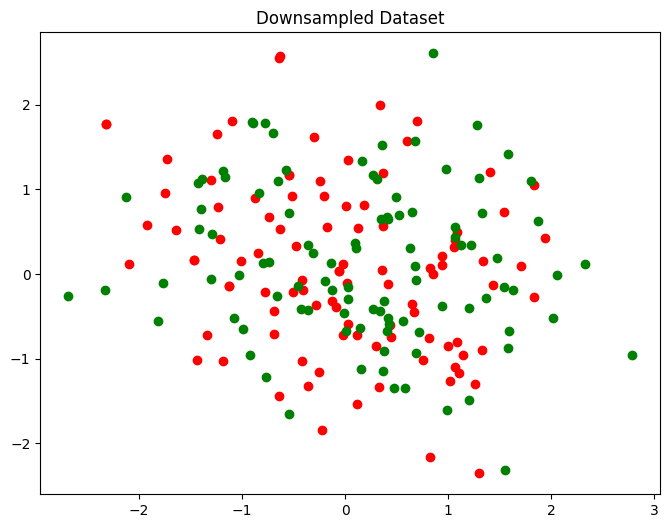

In [147]:
import matplotlib.pyplot as plt
df_0=df_downsampled[df_downsampled['target']==0]
df_1=df_downsampled[df_downsampled['target']==1]
plt.figure(figsize=(8, 6))
plt.scatter(df_0['feature_1'],df_0['feature_2'],color='red')
plt.scatter(df_1['feature_1'],df_1['feature_2'],color='green')
plt.title("Downsampled Dataset")

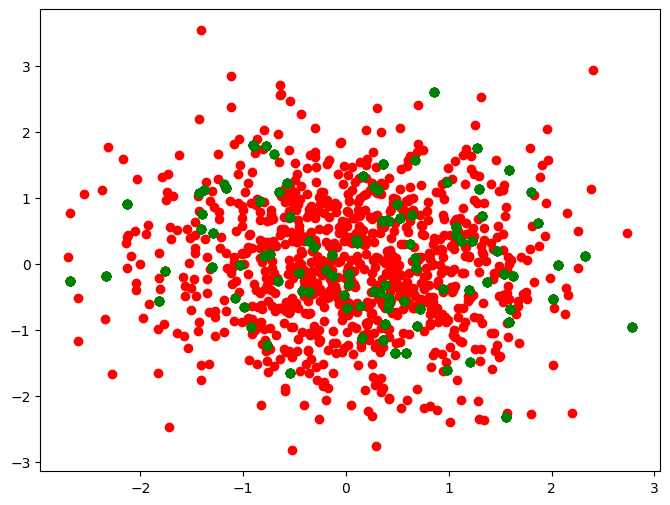

In [150]:
df_0=df_upsampled[df_upsampled['target']==0]
df_1=df_upsampled[df_upsampled['target']==1]
plt.figure(figsize=(8, 6))
plt.scatter(df_0['feature_1'],df_0['feature_2'],color='red')
plt.scatter(df_1['feature_1'],df_1['feature_2'],color='green')

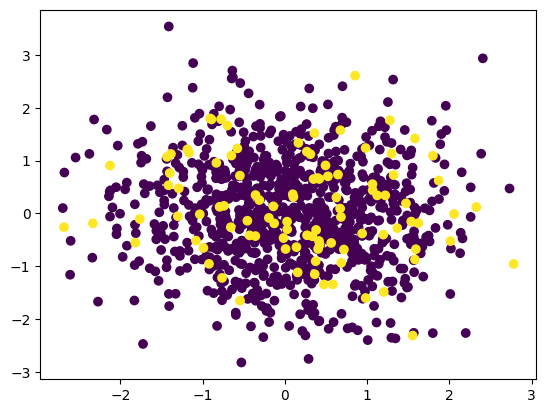

In [151]:
plt.scatter(df['feature_1'],df['feature_2'],c=df['target'])